Original shape: (1797, 64)
Features: 64

2D PCA:
Variance explained: 28.51%

50D PCA:
Variance explained: 99.95%

Components for 95% variance: 29


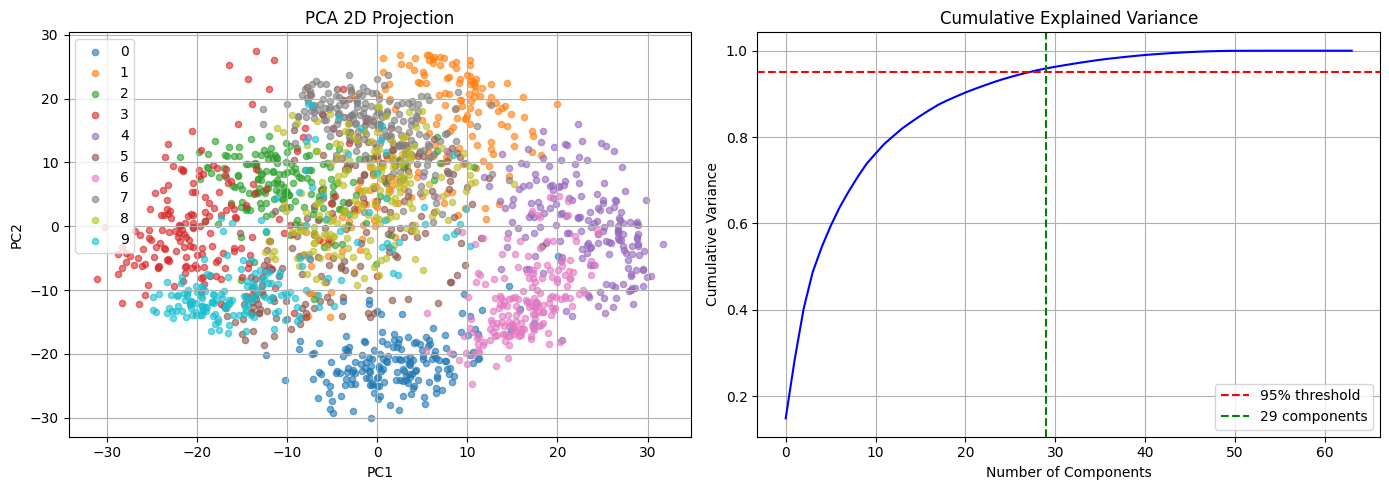

In [ ]:
"""
Assignment 3: PCA
Dimensionality Reduction
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

# Load digit dataset
digits = load_digits()
X = digits.data
y = digits.target

print(f"Original shape: {X.shape}")
print(f"Features: {X.shape[1]}")

# PCA to 2D
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X)

variance_2d = pca_2d.explained_variance_ratio_.sum()
print(f"\n2D PCA:")
print(f"Variance explained: {variance_2d:.2%}")

# PCA to 50D
pca_50d = PCA(n_components=50)
X_50d = pca_50d.fit_transform(X)

variance_50d = pca_50d.explained_variance_ratio_.sum()
print(f"\n50D PCA:")
print(f"Variance explained: {variance_50d:.2%}")

# Cumulative variance
pca_full = PCA()
pca_full.fit(X)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f"\nComponents for 95% variance: {n_components_95}")

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 2D scatter plot
for digit in range(10):
    mask = y == digit
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1], label=str(digit), s=20, alpha=0.6)

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('PCA 2D Projection')
ax1.legend()
ax1.grid(True)

# Cumulative variance plot
ax2.plot(cumsum, 'b-')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} components')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('assignment3_pca.png')